In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml as oml
import seaborn as sns


In [2]:
# Download Covertype data. Takes a while the first time.
covertype = oml.datasets.get_dataset(180, download_all_files=True)
X, y, _, _ = covertype.get_data(target=covertype.default_target_attribute, dataset_format='array'); 
classes = covertype.retrieve_class_labels()
features = [f.name for i,f in covertype.features.items()][:-1]

C:\Users\rsayf\AppData\Local\Temp\ipykernel_28576\207615622.py:2: FutureWarning: ``download_all_files`` is experimental and is likely to break with new releases.
  covertype = oml.datasets.get_dataset(180, download_all_files=True)
C:\Users\rsayf\AppData\Local\Temp\ipykernel_28576\207615622.py:3: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = covertype.get_data(target=covertype.default_target_attribute, dataset_format='array');


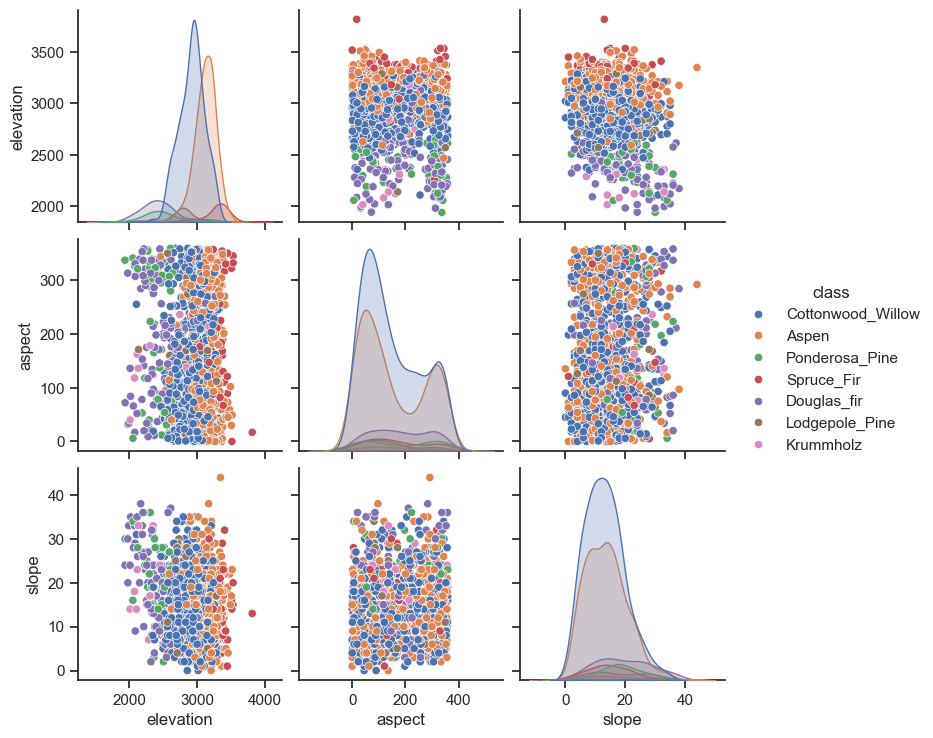

In [3]:
# Using seaborn to build the scatter matrix
# only first 3 columns, first 1000 examples
n_points = 1500
df = pd.DataFrame(X[:n_points,:3], columns=features[:3])
df['class'] = [classes[i] for i in y[:n_points]]
sns.set(style="ticks")
sns.pairplot(df, hue="class");

ex1

In [4]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate

def evaluate_RF(models, X, y, metric="accuracy", return_fit_time: bool = False):

    train_scores, test_scores = [], []
    fit_time = []

    for model in models: 

        cv_results = cross_validate(model, X, y, scoring=metric, return_train_score=True, verbose=1, cv=3)

        train_scores.append(cv_results["train_score"])
        test_scores.append(cv_results["test_score"])
        fit_time.append(cv_results["fit_time"])

    if return_fit_time:
        return test_scores, test_scores, fit_time
    
    return test_scores, test_scores

In [5]:
X_half = X[0:len(X)//2]
y_half = y[0:len(y)//2]

In [6]:
models = [
    RandomForestClassifier(n_estimators=j, max_depth=i, random_state=1) for i in [2, 8, 32, 64] for j in range(5, 31, 5)
]
params = [(i, j) for i in [2, 8, 32, 64] for j in range(5, 31, 5)]
print(params)

[(2, 5), (2, 10), (2, 15), (2, 20), (2, 25), (2, 30), (8, 5), (8, 10), (8, 15), (8, 20), (8, 25), (8, 30), (32, 5), (32, 10), (32, 15), (32, 20), (32, 25), (32, 30), (64, 5), (64, 10), (64, 15), (64, 20), (64, 25), (64, 30)]


In [7]:
train_scores, test_scores = evaluate_RF(models, X_half, y_half, "accuracy") 

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.4s finished
[Parallel(n_jobs=1)]

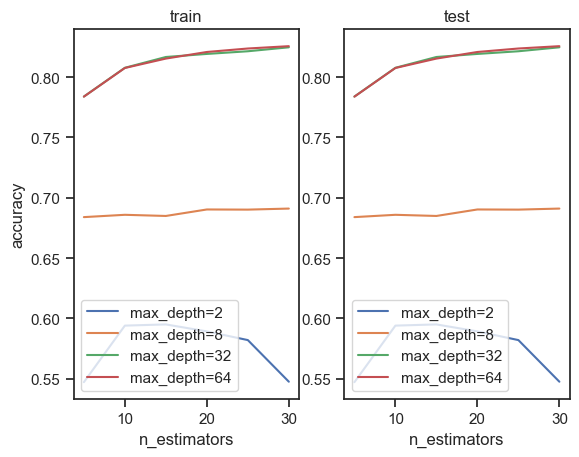

In [8]:
train_scores = np.array(train_scores)
test_scores = np.array(test_scores)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2)
for index, i in enumerate([2, 8, 32, 64]):
    ax1.plot(range(5, 31, 5), train_scores_mean[index*6:index*6+6], label=f"max_depth={i}")
    ax2.plot(range(5, 31, 5), test_scores_mean[index*6:index*6+6], label=f"max_depth={i}")
ax1.legend()
ax2.legend()
ax1.set_xlabel("n_estimators")
ax2.set_xlabel("n_estimators")
ax1.set_ylabel("accuracy")
#ax2.set_ylabel("accuracy")
ax1.set_title("train")
ax2.set_title("test")
plt.show()


ex2

In [9]:
models = [
    RandomForestClassifier(n_estimators=j, max_depth=64, random_state=1) for j in range(5, 31, 5)
]

In [27]:
train_scores, test_scores, fit_time = evaluate_RF(models, X_half, y_half, "balanced_accuracy", return_fit_time=True) 

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.4s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.8s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    3.5s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    4.3s finished


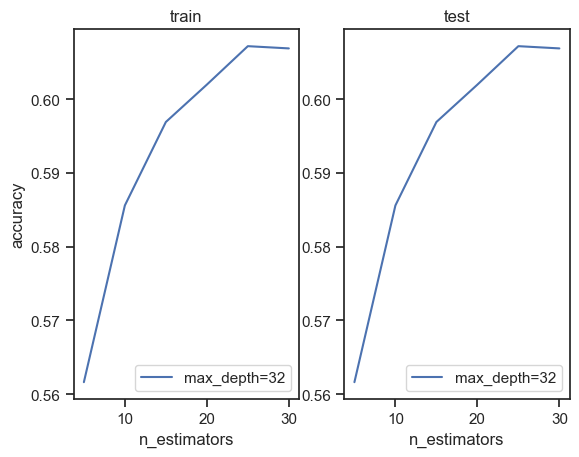

In [26]:
train_scores = np.array(train_scores)
test_scores = np.array(test_scores)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2)
for index, i in enumerate([32]):
    ax1.plot(range(5, 31, 5), train_scores_mean[index*6:index*6+6], label=f"max_depth={i}")
    ax2.plot(range(5, 31, 5), test_scores_mean[index*6:index*6+6], label=f"max_depth={i}")
ax1.legend()
ax2.legend()
ax1.set_xlabel("n_estimators")
ax2.set_xlabel("n_estimators")
ax1.set_ylabel("accuracy")
#ax2.set_ylabel("accuracy")
ax1.set_title("train")
ax2.set_title("test")
plt.show()


ex 3

(54,)
(54,)


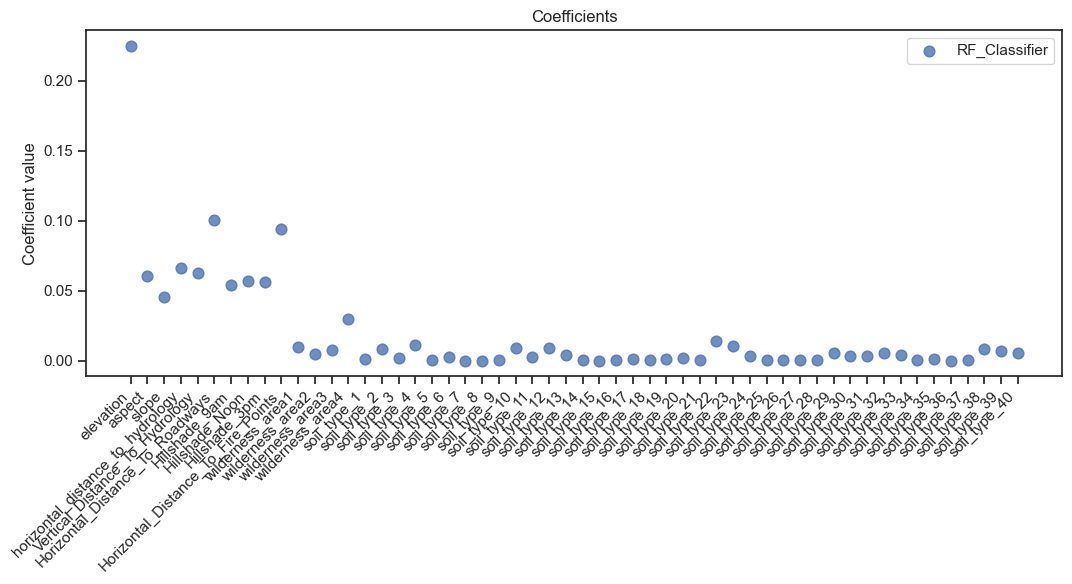

In [12]:
feature_names = features

def extract_feature_importances(model):
    return model.feature_importances_


def plot_coefficients(models_dict, title):
    plt.figure(figsize=(11, 6))
    x_axis = np.arange(len(feature_names))
    for model_name, model in models_dict.items():
        model.fit(X_half, y_half)
        coefs = extract_feature_importances(model)
        print(x_axis.shape)
        print(coefs.shape)
        plt.scatter(x_axis, coefs, label=model_name, s=60, alpha=0.8)
    plt.xticks(x_axis, feature_names, rotation=45, ha="right")
    plt.ylabel("Coefficient value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

model = {"RF_Classifier": RandomForestClassifier(n_estimators=25, max_depth=32, random_state=1)}
plot_coefficients(model, "Coefficients")

ex4

In [13]:
X_half_shorted = X_half[:, 0:10]
print(X_half_shorted.shape)

(55196, 10)


In [14]:
models = [
    RandomForestClassifier(n_estimators=j, max_depth=32, random_state=1) for j in range(5, 31, 5)
]

In [15]:
_, test_scores_shorted, fit_time_shorted = evaluate_RF(models, X_half_shorted, y_half, "balanced_accuracy", True) 

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.8s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    3.9s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    4.7s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    5.7s finished


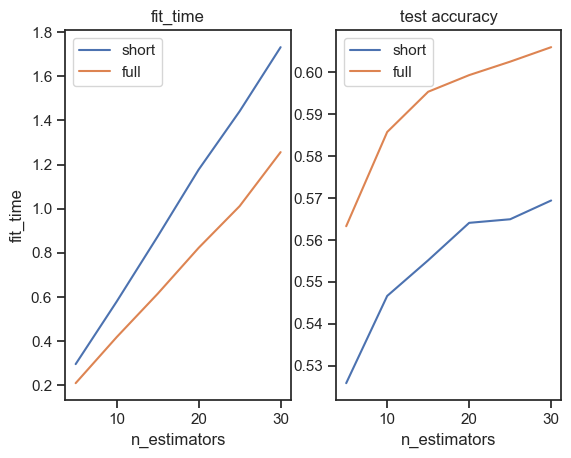

In [32]:
fit_time = np.array(fit_time)
fit_time_shorted = np.array(fit_time_shorted)
test_scores = np.array(test_scores)
test_scores_shorted = np.array(test_scores_shorted)
fit_time_mean = np.mean(fit_time, axis=1)
fit_time_shorted_mean = np.mean(fit_time_shorted, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_shorted_mean = np.mean(test_scores_shorted ,axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2)
for index, i in enumerate([32]):
    ax1.plot(range(5, 31, 5), fit_time_shorted_mean[index*6:index*6+6], label=f"short")
    ax1.plot(range(5, 31, 5), fit_time_mean[index*6:index*6+6], label="full")
    ax2.plot(range(5, 31, 5), test_scores_shorted_mean[index*6:index*6+6], label=f"short")
    ax2.plot(range(5, 31, 5), test_scores_mean[index*6:index*6+6], label=f"full")
ax1.legend()
ax2.legend()
ax1.set_xlabel("n_estimators")
ax2.set_xlabel("n_estimators")
ax1.set_ylabel("fit_time")
#ax2.set_ylabel("accuracy")
ax1.set_title("fit_time")
ax2.set_title("test accuracy")
plt.show()

ex5

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    stratify=y,          
    random_state=1      
)

X_train = X_train[:, 0:10]
X_test = X_test[:, 0:10]

In [18]:
model = RandomForestClassifier(n_estimators=25, max_depth=32).fit(X_train, y_train)

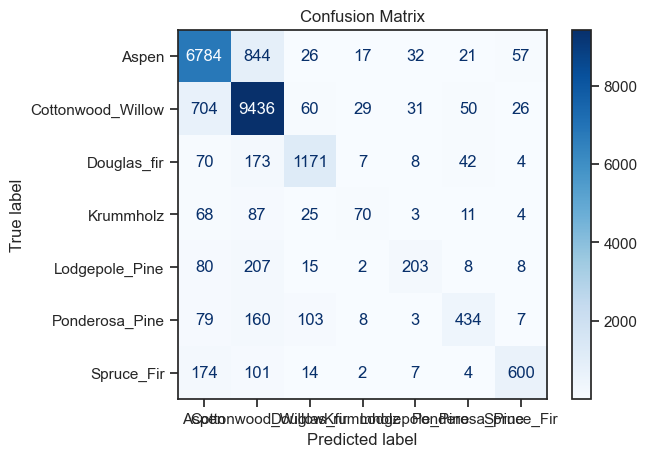

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues) # Выбираем цветовую схему
plt.title("Confusion Matrix")
plt.show()

ex5

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    stratify=y,          
    random_state=1      
)

X_train = X_train[:, 0:10]
X_test = X_test[:, 0:10]

train_cond = (y_train == 0) | (y_train == 1)
X_train = X_train[train_cond]
y_train = y_train[train_cond]

test_cond = (y_test == 0) | (y_test == 1)
X_test = X_test[test_cond]
y_test = y_test[test_cond]


In [21]:
model = RandomForestClassifier(n_estimators=25, max_depth=32).fit(X_train, y_train)

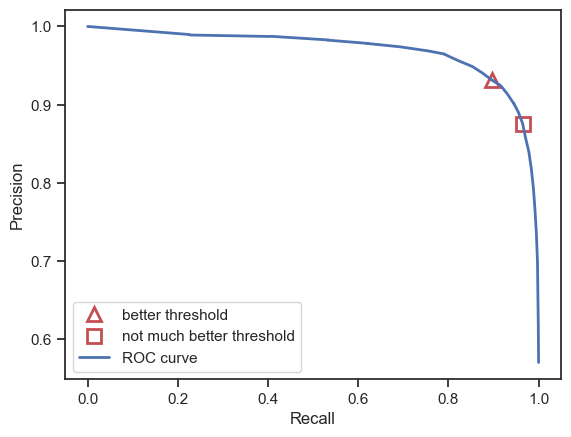

In [22]:
from sklearn.metrics import precision_recall_curve

# SVC is not probabilistic, so we use the decision function to get the ROC curve
precision, recall, thresholds = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])

# # Find threshold closest to 0
# close_zero = np.argmin(np.abs(thresholds)) # minimum theshold = maximum precision
# plt.plot(recall[close_zero], precision[close_zero], 'o', markersize=10, label="threshold zero", fillstyle="none", c='k', mew=2)

threshold = 0.6 # really beter recall, not big breaking of precision and grow up of recall
close_t = np.argmin(np.abs(thresholds-threshold))
plt.plot(recall[close_t], precision[close_t], '^', markersize=10, label="better threshold", fillstyle="none", c='r', mew=2)

threshold = 0.4 # threshold that break precision too mach
close_t = np.argmin(np.abs(thresholds-threshold))
plt.plot(recall[close_t], precision[close_t], 's', markersize=10, label="not much better threshold", fillstyle="none", c='r', mew=2)

plt.plot(recall, precision, lw=2, label="ROC curve")
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")

ex7

C:\Users\rsayf\AppData\Local\Temp\ipykernel_28576\3585472681.py:1: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = covertype.get_data(target=covertype.default_target_attribute, dataset_format='array');


54
54


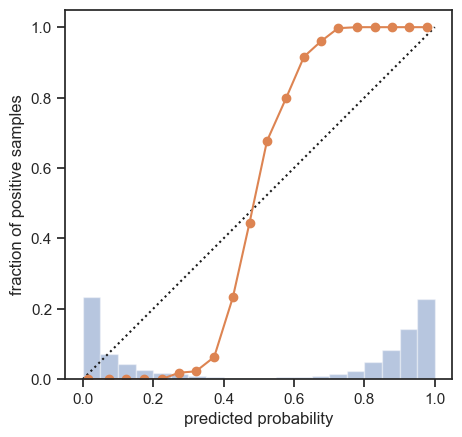

In [23]:

X, y, _, _ = covertype.get_data(target=covertype.default_target_attribute, dataset_format='array'); 
X_bin = X[y < 2, :]
y_bin = y[y < 2]
X_train, X_test, y_train, y_test = train_test_split(X_bin, y_bin, stratify=y_bin, random_state=1)

print(X.shape[1])       # Количество фич для первой модели
print(X_test.shape[1])  # Количество фич для второй модели

# Model Solution
from sklearn.calibration import calibration_curve
def plot_calibration_curve(y_true, y_prob, n_bins=5, ax=None, hist=True):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    if ax is None:
        ax = plt.gca()
    if hist:
        ax.hist(y_prob, weights=np.ones_like(y_prob) / len(y_prob), alpha=.4,
               bins=np.maximum(10, n_bins))
    ax.plot([0, 1], [0, 1], ':', c='k')
    curve = ax.plot(prob_pred, prob_true, marker="o")

    ax.set_xlabel("predicted probability")
    ax.set_ylabel("fraction of positive samples")

    ax.set(aspect='equal')
    return curve

forest = RandomForestClassifier(random_state=1, n_estimators=25, max_depth=32, n_jobs=-1).fit(X, y)
binary_forest = RandomForestClassifier(random_state=1, n_estimators=25, max_depth=32, n_jobs=-1).fit(X_train, y_train)
scores = forest.predict_proba(X_test)[:, 1]
plot_calibration_curve(y_test, scores, n_bins=20);



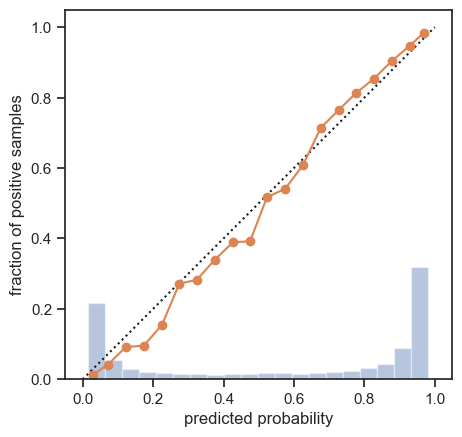

In [24]:
from sklearn.calibration import CalibratedClassifierCV
rf = RandomForestClassifier(random_state=0, n_estimators=25, max_depth=32, n_jobs=-1) #Unfitted RF
sigmoid = CalibratedClassifierCV(rf, cv=2, method='sigmoid')
sigmoid.fit(X_train, y_train)
y_pred = sigmoid.predict(X_test)
prob_pos = sigmoid.predict_proba(X_test)[:, 1]
plot_calibration_curve(y_test, prob_pos, n_bins=20)

ex8

c:\Users\rsayf\.conda\envs\ml_course\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


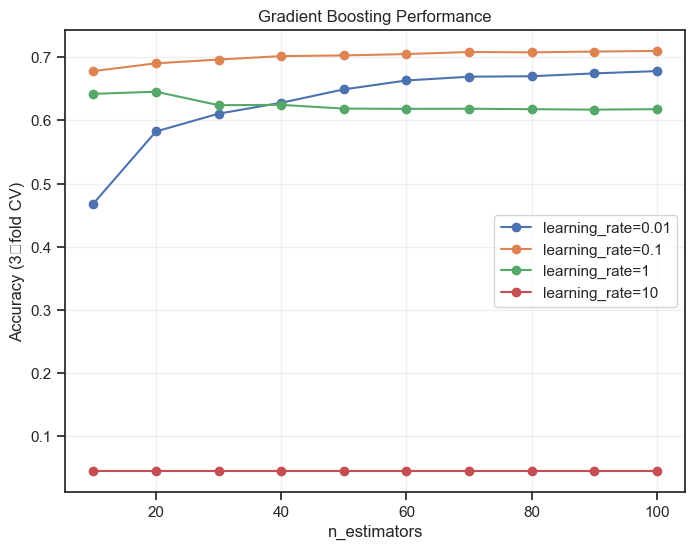

Best accuracy for every learning rate:
  lr=0.01: 0.6782 with n_estimators=100
  lr=0.1: 0.7101 with n_estimators=100
  lr=1: 0.6456 with n_estimators=20
  lr=10: 0.0448 with n_estimators=10


In [25]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split

def evaluate_GB(X, y, n_estimators, learning_rates=[0.01, 0.1, 1, 10], scoring='accuracy'):
    """
    Оценивает GradientBoostingClassifier для заданного n_estimators и списка learning_rates.
    Возвращает словарь: ключ = learning_rate, значение = средняя точность на 3‑fold CV.
    """
    scores = {}
    kfold = StratifiedKFold(n_splits=3, random_state=1, shuffle=True)
    for lr in learning_rates:
        model = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=lr, random_state=1)
        cv_scores = cross_val_score(model, X, y, cv=kfold, scoring=scoring)
        scores[f"lr={lr}"] = np.mean(cv_scores)
    return scores

X_sample, _, y_sample, _ = train_test_split(X, y, stratify=y, train_size=0.05, random_state=1)

n_estimators_range = range(10, 101, 10)

results = {lr: [] for lr in [0.01, 0.1, 1, 10]}

for n in n_estimators_range:
    scores = evaluate_GB(X_sample, y_sample, n, learning_rates=list(results.keys()), scoring='accuracy')
    for lr in results.keys():
        results[lr].append(scores[f"lr={lr}"])

plt.figure(figsize=(8, 6))
for lr, scores in results.items():
    plt.plot(n_estimators_range, scores, marker='o', label=f'learning_rate={lr}')

plt.xlabel('n_estimators')
plt.ylabel('Accuracy (3‑fold CV)')
plt.title('Gradient Boosting Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Best accuracy for every learning rate:")
for lr, scores in results.items():
    best = np.max(scores)
    best_n = n_estimators_range[np.argmax(scores)]
    print(f"  lr={lr}: {best:.4f} with n_estimators={best_n}")

